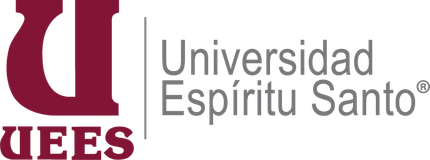

<div style="background:#821436;color:#FFFFFF;padding:14px 18px;border-radius:10px;margin:6px 0 12px 0"><div style="font-size:12px;letter-spacing:.08em;text-transform:uppercase;opacity:.9">Aprendizaje Automático · MIAR0525 · Semana 1 · Versión resuelta · referencia</div><div style="font-size:22px;font-weight:700;margin-top:4px">E1.2 · Métricas y costo del error</div><div style="font-size:12px;opacity:.9;margin-top:4px">Postgrado · Maestría en Inteligencia Artificial · UEES</div></div>

| | |
|---|---|
| **Objetivo** | Elegir métricas y umbral según el costo del error, en lugar de usar la exactitud y 0.5 por defecto. |
| **Resultado de aprendizaje** | RDA1 · competencias CG-G1 y CE-G1 |
| **Duración** | ≈ 4.5 h |
| **Teoría** | Manual M1 §6 · Animación A1.6 · Video V1.3 |
| **Datos** | Puntajes simulados · **kc1**: defectos de software de la NASA (OpenML 1067; 2109 módulos, 21 métricas de código, 15.5 % defectuosos) |

**Niveles:** 1 · métricas y curvas desde cero → 2 · scikit-learn → 3 · umbral por costo en datos reales → 4 · reto.

## 0 · Configuración

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from cycler import cycler

warnings.filterwarnings("ignore", category=FutureWarning)
SEED = 2026
UEES = {"vino": "#821436", "azul": "#1F6F8B", "ocre": "#C28E0E", "verde": "#3A7D44", "gris": "#77787B"}
plt.rcParams.update({
    "axes.prop_cycle": cycler(color=list(UEES.values())), "axes.titlecolor": UEES["vino"],
    "axes.titleweight": "bold", "axes.edgecolor": UEES["gris"], "axes.grid": True, "grid.color": "#EEE8EA",
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110, "legend.frameon": False,
})
trapecio = getattr(np, "trapezoid", None) or np.trapz      # NumPy ≥ 2 usa trapezoid
print(f"scikit-learn {sklearn.__version__} · semilla {SEED}")

scikit-learn 1.9.1 · semilla 2026


## Nivel 1 · Desde cero

Simulamos 1000 casos con 20 % de positivos y un modelo que da un **puntaje** entre 0 y 1: los positivos tienden a recibir puntajes más altos, pero las dos distribuciones se solapan (como en la animación A1.6).

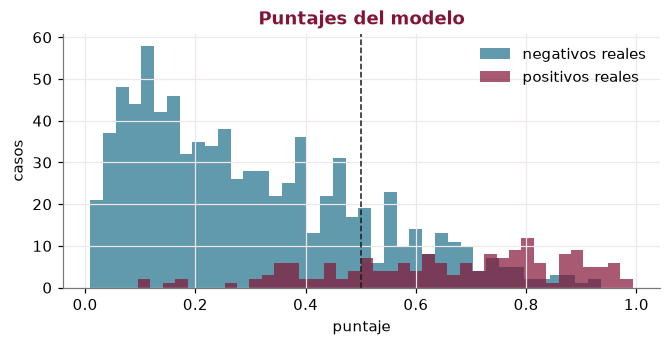

In [2]:
rng = np.random.default_rng(SEED)
n = 1000
y_sim = (rng.random(n) < 0.20).astype(int)
z = rng.normal(np.where(y_sim == 1, 1.0, -1.0), 1.2)
p_sim = 1 / (1 + np.exp(-z))

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(p_sim[y_sim == 0], bins=40, alpha=0.7, label="negativos reales", color=UEES["azul"])
ax.hist(p_sim[y_sim == 1], bins=40, alpha=0.7, label="positivos reales", color=UEES["vino"])
ax.axvline(0.5, color="#1C1A1B", ls="--", lw=1)
ax.set(title="Puntajes del modelo", xlabel="puntaje", ylabel="casos")
ax.legend()
plt.show()

### 1.1 Matriz de confusión y métricas
Con un umbral $t$, el modelo predice positivo si el puntaje es $\ge t$.

$$\text{precisión}=\frac{VP}{VP+FP}\qquad \text{recall}=\frac{VP}{VP+FN}\qquad F_1=\frac{2\,\text{precisión}\cdot\text{recall}}{\text{precisión}+\text{recall}}\qquad \text{tasa de FP}=\frac{FP}{FP+VN}$$

In [3]:
def matriz_confusion(y, y_pred):
    """Devuelve (VP, FP, FN, VN)."""
    y, y_pred = np.asarray(y), np.asarray(y_pred)
    # TODO: cuenta cada celda comparando y (real) con y_pred (predicho).
    vp = int(np.sum((y == 1) & (y_pred == 1)))
    fp = int(np.sum((y == 0) & (y_pred == 1)))
    fn = int(np.sum((y == 1) & (y_pred == 0)))
    vn = int(np.sum((y == 0) & (y_pred == 0)))
    return vp, fp, fn, vn


def metricas(vp, fp, fn, vn):
    # TODO: calcula precisión, recall, F1, exactitud y tasa de falsos positivos (cuida las divisiones por cero).
    precision = vp / (vp + fp) if vp + fp else 0.0
    recall = vp / (vp + fn) if vp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    exactitud = (vp + vn) / (vp + fp + fn + vn)
    tfp = fp / (fp + vn) if fp + vn else 0.0
    return {"precisión": precision, "recall": recall, "F1": f1, "exactitud": exactitud, "tasa FP": tfp}


filas = {}
for t in (0.3, 0.5, 0.7):
    vp, fp, fn, vn = matriz_confusion(y_sim, (p_sim >= t).astype(int))
    filas[f"umbral {t}"] = {"VP": vp, "FP": fp, "FN": fn, "VN": vn, **metricas(vp, fp, fn, vn)}
pd.DataFrame(filas).T.round(3)

,VP,FP,FN,VN,precisión,recall,F1,exactitud,tasa FP
umbral 0.3,163.0,353.0,6.0,478.0,0.316,0.964,0.476,0.641,0.425
umbral 0.5,129.0,145.0,40.0,686.0,0.471,0.763,0.582,0.815,0.174
umbral 0.7,82.0,36.0,87.0,795.0,0.695,0.485,0.571,0.877,0.043


**Qué observar.** Al subir el umbral baja la tasa de falsos positivos y sube la precisión, pero cae el recall: se escapan más positivos. Ningún umbral mejora todo a la vez.

### 1.2 Curvas ROC y precisión-recall
Ordenamos los casos de mayor a menor puntaje y bajamos el umbral uno por uno: cada caso que entra suma un VP (si era positivo) o un FP (si era negativo).

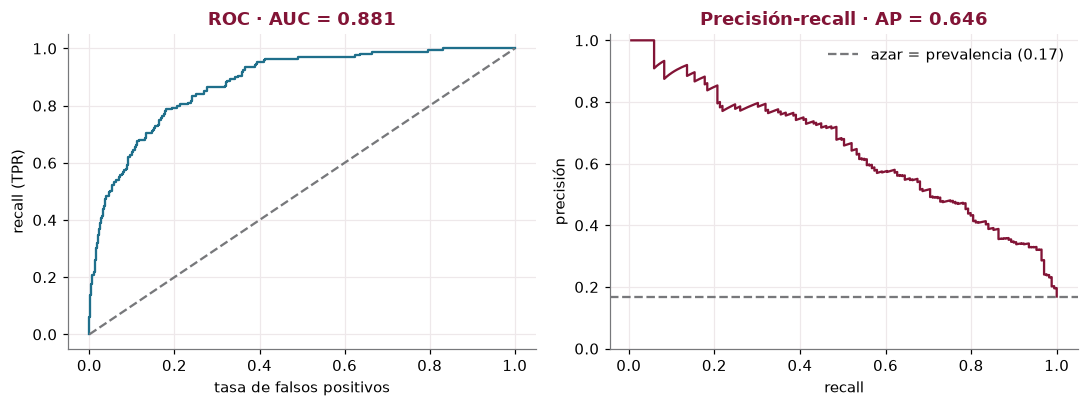

In [4]:
def curvas_roc_pr(y, puntaje):
    """Devuelve fpr, tpr (con el punto (0, 0) al inicio), precisión y recall para todos los umbrales."""
    y = np.asarray(y)
    orden = np.argsort(-puntaje)
    y_ord = y[orden]
    # TODO: acumula VP y FP con np.cumsum y calcula las tasas.
    vp = np.cumsum(y_ord)
    fp = np.cumsum(1 - y_ord)
    positivos, negativos = y.sum(), len(y) - y.sum()
    tpr = np.concatenate([[0.0], vp / positivos])
    fpr = np.concatenate([[0.0], fp / negativos])
    precision = vp / (vp + fp)
    recall = vp / positivos
    return fpr, tpr, precision, recall


fpr, tpr, prec, rec = curvas_roc_pr(y_sim, p_sim)
auc_propio = trapecio(tpr, fpr)
ap_propio = float(np.sum(np.diff(np.concatenate([[0.0], rec])) * prec))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].plot(fpr, tpr, color=UEES["azul"])
axes[0].plot([0, 1], [0, 1], ls="--", color=UEES["gris"])
axes[0].set(title=f"ROC · AUC = {auc_propio:.3f}", xlabel="tasa de falsos positivos", ylabel="recall (TPR)")
axes[1].plot(rec, prec, color=UEES["vino"])
axes[1].axhline(y_sim.mean(), ls="--", color=UEES["gris"], label=f"azar = prevalencia ({y_sim.mean():.2f})")
axes[1].set(title=f"Precisión-recall · AP = {ap_propio:.3f}", xlabel="recall", ylabel="precisión", ylim=(0, 1.02))
axes[1].legend()
plt.tight_layout()
plt.show()

## Nivel 2 · Con scikit-learn
Las mismas métricas con la librería. Si tus funciones son correctas, los números coinciden exactamente.

In [5]:
from sklearn.metrics import (PrecisionRecallDisplay, RocCurveDisplay, average_precision_score, classification_report,
                             confusion_matrix, roc_auc_score)

y_pred05 = (p_sim >= 0.5).astype(int)
vn_sk, fp_sk, fn_sk, vp_sk = confusion_matrix(y_sim, y_pred05).ravel()
print(classification_report(y_sim, y_pred05, digits=3))
print(f"AUC-ROC · scikit-learn {roc_auc_score(y_sim, p_sim):.6f} · tuyo {auc_propio:.6f}")
print(f"PR-AUC  · scikit-learn {average_precision_score(y_sim, p_sim):.6f} · tuyo {ap_propio:.6f}")
assert (vp_sk, fp_sk, fn_sk, vn_sk) == matriz_confusion(y_sim, y_pred05), "Tu matriz de confusión no coincide."
assert np.isclose(roc_auc_score(y_sim, p_sim), auc_propio), "Tu AUC-ROC no coincide."
assert np.isclose(average_precision_score(y_sim, p_sim), ap_propio), "Tu PR-AUC no coincide."
print("✓ Tus métricas coinciden con scikit-learn")

              precision    recall  f1-score   support

           0      0.945     0.826     0.881       831
           1      0.471     0.763     0.582       169

    accuracy                          0.815      1000
   macro avg      0.708     0.794     0.732      1000
weighted avg      0.865     0.815     0.831      1000

AUC-ROC · scikit-learn 0.881472 · tuyo 0.881472
PR-AUC  · scikit-learn 0.646354 · tuyo 0.646354
✓ Tus métricas coinciden con scikit-learn


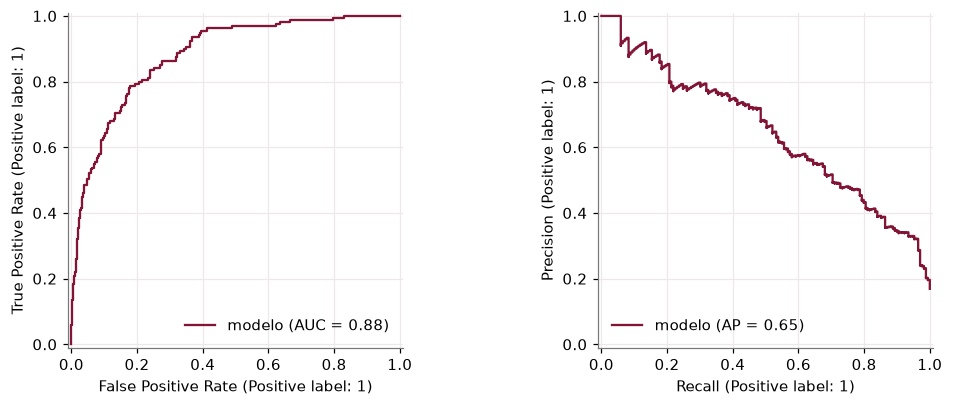

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
# (el color sale del ciclo de la paleta UEES; así el código funciona igual en todas las versiones de scikit-learn)
RocCurveDisplay.from_predictions(y_sim, p_sim, ax=axes[0], name="modelo")
PrecisionRecallDisplay.from_predictions(y_sim, p_sim, ax=axes[1], name="modelo")
plt.tight_layout()
plt.show()

## Nivel 3 · Datos reales: defectos de software (kc1)

Cada fila es un módulo de software con métricas de código (líneas, complejidad ciclomática, operadores…). El objetivo `defects` indica si tuvo defectos. **Dejar pasar un módulo defectuoso cuesta 5 veces más que revisar uno sano**: $c_{FN}=5$, $c_{FP}=1$. Elegiremos el umbral que minimiza el costo usando **validación cruzada**, nunca la prueba.

In [7]:
from sklearn.datasets import fetch_openml
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

kc1 = fetch_openml(data_id=1067, as_frame=True)
X_k = kc1.data
y_k = (kc1.target == "true").astype(int)
print(f"{X_k.shape[0]} módulos · {X_k.shape[1]} variables · {y_k.mean():.1%} defectuosos")

Xk_tr, Xk_te, yk_tr, yk_te = train_test_split(X_k, y_k, test_size=0.2, stratify=y_k, random_state=SEED)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
modelo = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
# Probabilidades "fuera del fold": cada fila recibe el puntaje de un modelo que no la vio al entrenar.
p_oof = cross_val_predict(modelo, Xk_tr, yk_tr, cv=cv, method="predict_proba")[:, 1]
print(f"PR-AUC en validación cruzada: {average_precision_score(yk_tr, p_oof):.3f} (azar = {yk_tr.mean():.3f})")

2109 módulos · 21 variables · 15.5% defectuosos
PR-AUC en validación cruzada: 0.442 (azar = 0.155)


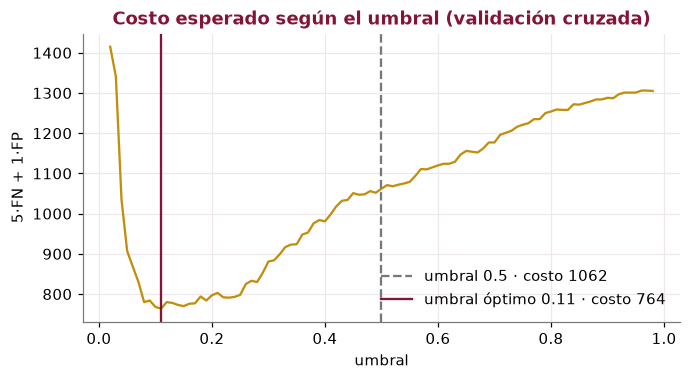

In [8]:
C_FN, C_FP = 5, 1


def costo_total(y, puntaje, umbral, c_fn=C_FN, c_fp=C_FP):
    """Costo = c_fn·FN + c_fp·FP con el umbral dado."""
    # TODO: usa matriz_confusion para obtener FN y FP y devuelve el costo.
    vp, fp, fn, vn = matriz_confusion(y, (np.asarray(puntaje) >= umbral).astype(int))
    return c_fn * fn + c_fp * fp


umbrales = np.round(np.linspace(0.02, 0.98, 97), 2)
costos = np.array([costo_total(yk_tr, p_oof, t) for t in umbrales])
t_opt = float(umbrales[np.argmin(costos)])

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(umbrales, costos, color=UEES["ocre"])
ax.axvline(0.5, color=UEES["gris"], ls="--", label=f"umbral 0.5 · costo {costo_total(yk_tr, p_oof, 0.5)}")
ax.axvline(t_opt, color=UEES["vino"], label=f"umbral óptimo {t_opt:.2f} · costo {costos.min()}")
ax.set(title="Costo esperado según el umbral (validación cruzada)", xlabel="umbral", ylabel=f"{C_FN}·FN + {C_FP}·FP")
ax.legend()
plt.show()

Ahora sí: entrenamos con todo el entrenamiento y evaluamos **una sola vez** en la prueba con los dos umbrales.

In [9]:
modelo.fit(Xk_tr, yk_tr)
p_te = modelo.predict_proba(Xk_te)[:, 1]
comparacion = {}
for nombre, t in (("umbral 0.5", 0.5), (f"umbral óptimo {t_opt:.2f}", t_opt)):
    vp, fp, fn, vn = matriz_confusion(yk_te, (p_te >= t).astype(int))
    comparacion[nombre] = {"VP": vp, "FP": fp, "FN": fn, "VN": vn, "costo": costo_total(yk_te, p_te, t),
                           "recall": round(vp / (vp + fn), 3), "precisión": round(vp / (vp + fp), 3) if vp + fp else 0.0}
pd.DataFrame(comparacion).T

,VP,FP,FN,VN,costo,recall,precisión
umbral 0.5,12.0,8.0,53.0,349.0,273.0,0.185,0.600
umbral óptimo 0.11,50.0,134.0,15.0,223.0,209.0,0.769,0.272


**Qué observar.** Con 0.5 el modelo casi no marca módulos (la clase positiva es minoritaria) y se escapan muchos defectos, que son el error caro. El umbral elegido por costo, bastante menor, reduce el costo total aunque revisemos más módulos sanos. **La métrica y el umbral son decisiones de negocio**, no valores por defecto.

## Nivel 4 · Reto

### 4.1 `TunedThresholdClassifierCV`
scikit-learn automatiza lo anterior: busca el umbral con validación cruzada según una métrica que tú defines.

In [10]:
from sklearn.metrics import make_scorer
from sklearn.model_selection import TunedThresholdClassifierCV


def costo_negativo(y_true, y_pred):
    """Menos el costo (scikit-learn maximiza los puntajes)."""
    vp, fp, fn, vn = matriz_confusion(y_true, y_pred)
    return -(C_FN * fn + C_FP * fp)


ajustado = TunedThresholdClassifierCV(modelo, scoring=make_scorer(costo_negativo), cv=cv, thresholds=97)
ajustado.fit(Xk_tr, yk_tr)
costo_te_ajustado = -costo_negativo(yk_te, ajustado.predict(Xk_te))
print(f"Umbral elegido por TunedThresholdClassifierCV: {ajustado.best_threshold_:.3f}")
print(f"Costo en prueba · umbral 0.5: {comparacion['umbral 0.5']['costo']} · ajustado: {costo_te_ajustado}")

Umbral elegido por TunedThresholdClassifierCV: 0.145
Costo en prueba · umbral 0.5: 273 · ajustado: 184


### 4.2 `class_weight` es otra palanca para lo mismo
Con `class_weight="balanced"` la regresión logística pesa más los positivos y sus puntajes se desplazan hacia arriba. Observa dónde queda ahora el umbral óptimo.

In [11]:
modelo_bal = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced"))
p_oof_bal = cross_val_predict(modelo_bal, Xk_tr, yk_tr, cv=cv, method="predict_proba")[:, 1]
costos_bal = np.array([costo_total(yk_tr, p_oof_bal, t) for t in umbrales])
t_opt_bal = float(umbrales[np.argmin(costos_bal)])
print(f"Umbral óptimo · sin class_weight: {t_opt:.2f} · con class_weight='balanced': {t_opt_bal:.2f}")
print(f"Costo mínimo en validación · sin: {costos.min()} · con: {costos_bal.min()}")

Umbral óptimo · sin class_weight: 0.11 · con class_weight='balanced': 0.41
Costo mínimo en validación · sin: 764 · con: 741


**Qué observar.** Con los pesos balanceados el umbral óptimo sube hacia 0.5, pero el costo mínimo es parecido: repesar las clases y mover el umbral son dos formas de expresar el mismo costo. Lo que no se puede es ignorarlo.

> **Respuesta de referencia**

**Reflexión · quién decide los costos.** Los costos $c_{FN}$ y $c_{FP}$ no los fija el científico de datos: salen de la operación (costo de una revisión de código, impacto de un defecto en producción) y deben acordarse con el área responsable y documentarse en el informe, junto con la sensibilidad del umbral a esos supuestos.

## Autoverificación

In [12]:
assert (vp_sk, fp_sk, fn_sk, vn_sk) == matriz_confusion(y_sim, y_pred05)
assert np.isclose(roc_auc_score(y_sim, p_sim), auc_propio) and np.isclose(average_precision_score(y_sim, p_sim), ap_propio)
assert t_opt < 0.5, "Con falsos negativos más caros, el umbral óptimo debería quedar por debajo de 0.5."
assert comparacion[f"umbral óptimo {t_opt:.2f}"]["costo"] < comparacion["umbral 0.5"]["costo"], "El umbral por costo debería reducir el costo en prueba."
print("✓ E1.2 completo")

✓ E1.2 completo


## Lista de cotejo (autoevaluación)

- [ ] Tus métricas y curvas desde cero coinciden con scikit-learn.
- [ ] Graficaste ROC y PR y sabes cuál preferir con clases desbalanceadas.
- [ ] Elegiste el umbral por costo con validación cruzada, no con la prueba.
- [ ] Comparaste el costo en prueba con el umbral 0.5.

**Reflexión:** ¿quién debería decidir los costos $c_{FN}$ y $c_{FP}$ en una organización real?

**Cómo te prepara para la Tarea 1:** la tarea pide justificar la métrica y el umbral con una matriz de costos (retener frente a perder un cliente).

## Desafío opcional con IA agéntica · El umbral de tu organización

**Objetivo.** Ver cómo cambian el umbral y la decisión cuando cambia el costo de cada error.

**Prompt inicial.** Úsalo en la herramienta que prefieras (Claude Code, Codex, Gemini en Colab, ChatGPT…), con este notebook resuelto como contexto. Pide primero un plan y revisa cada paso antes de aprobarlo.

```text
En el notebook resuelto E1.2 (métricas y umbral por costo con los defectos de software kc1), agrega una sección que compare tres escenarios de costo FN:FP = 1:1, 5:1 y 20:1. Para cada uno elige el umbral por validación cruzada con TunedThresholdClassifierCV, sin usar la prueba, y reporta precisión, recall y costo esperado en la prueba. Resume en una tabla y explica qué escenario usarías en un equipo de QA con poca capacidad de revisión.
```

**Cómo verificar el resultado**

- El umbral se elige sin mirar la prueba.
- Los umbrales bajan cuando el falso negativo se vuelve más caro.
- La conclusión habla de costos y capacidad, no solo de F1.

**Declara el uso de IA** (norma f del sílabo): herramienta, prompts relevantes, qué verificaste tú y qué corregiste. El desafío es opcional y no se califica; lo que cuenta es que puedas explicar cada decisión.